   ID  Year_Birth Education Marital_Status  Income  MntWines  MntFruits  \
0   1        1998    Master        Married   55111       792        101   
1   2        1988     Basic         Single   57904       791        266   
2   3        1974     Basic         Single   74912       523        109   
3   4        1967    Master         Single   54008       785        264   
4   5        1980       PhD         Single   20060       270          2   

   MntGoldProds  NumWebPurchases  NumStorePurchases  AcceptedCmp1  \
0           131                7                  5             0   
1           110                7                  3             0   
2           380               11                 17             0   
3           131               14                  8             0   
4            19                6                 16             1   

   AcceptedCmp2  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  Response  
0             0             0             0             0       

C:\Users\a13sy\AppData\Local\Temp\ipykernel_15324\3301728116.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].mean(), inplace=True)


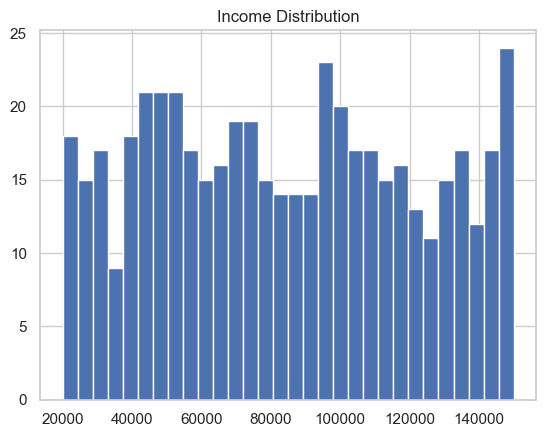

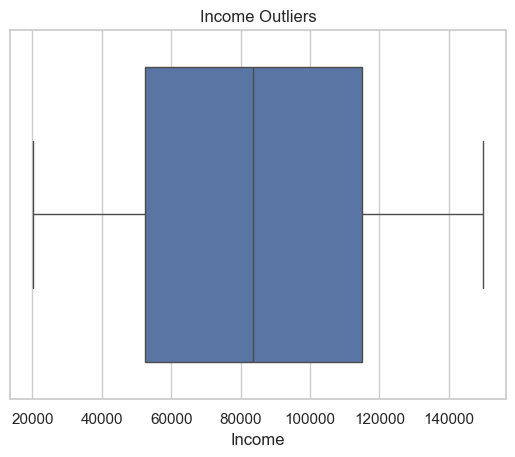

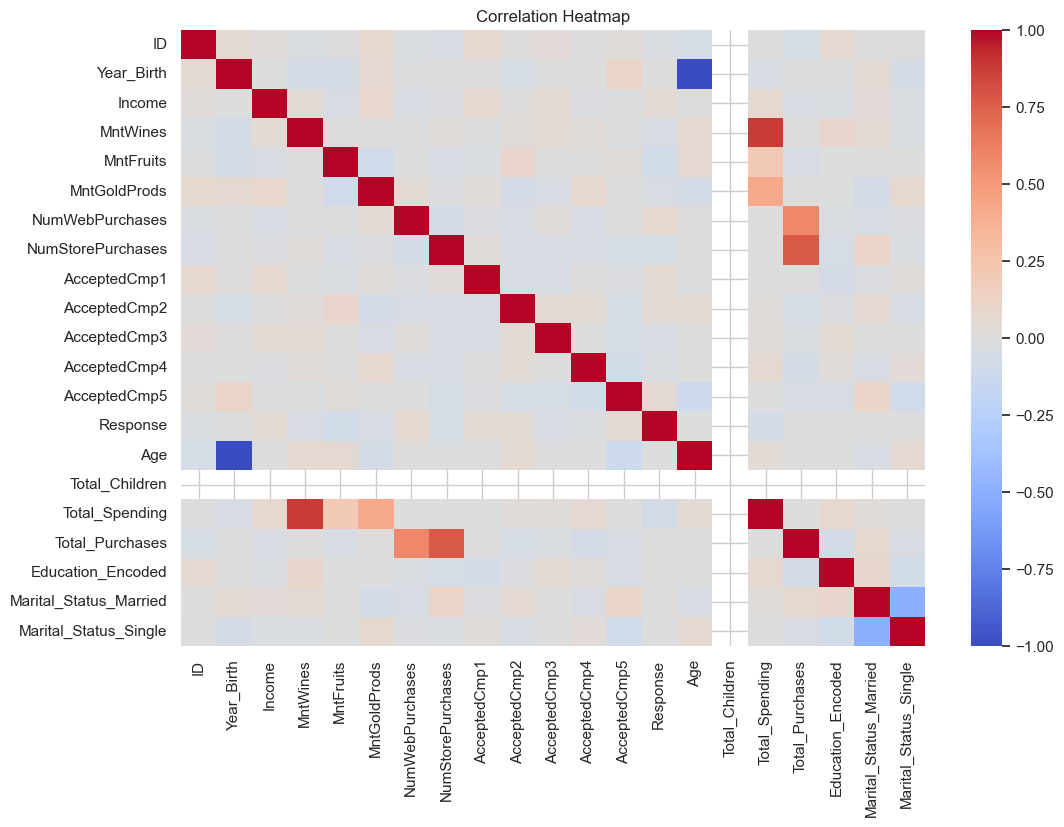

Age vs Store Purchases Correlation: -0.012906892544362015
Children vs Web Purchases Correlation: nan
Store vs Web Purchases Correlation: -0.07370608819254748


C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


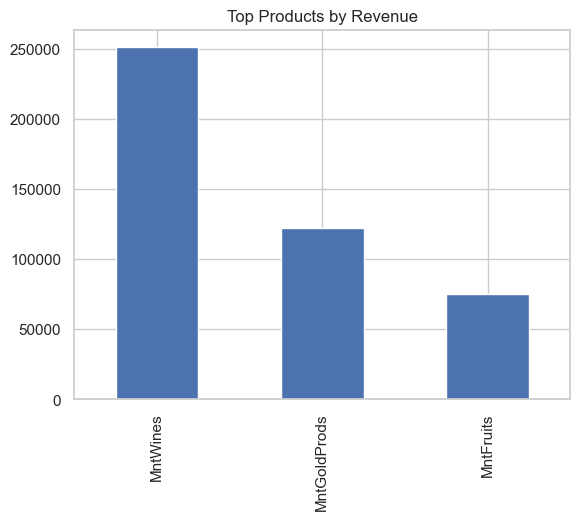

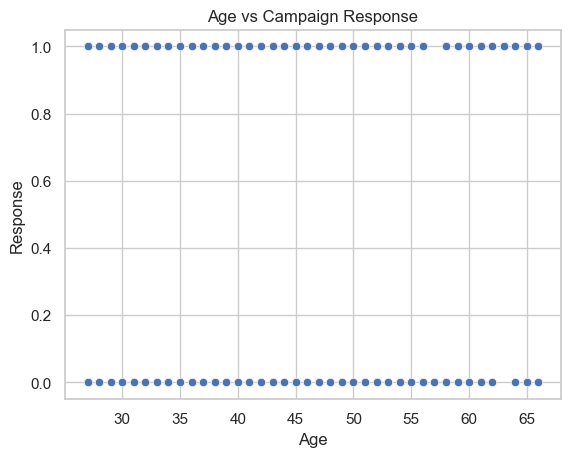

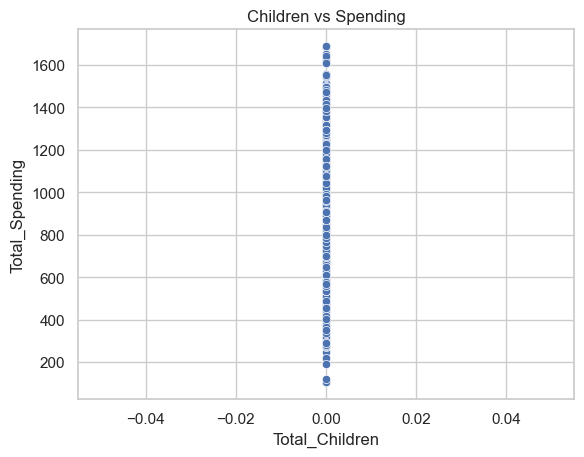

In [2]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from scipy import stats

sns.set(style="whitegrid")

# =========================================
# 2. LOAD DATA
# =========================================
file_path=r"C:\Users\a13sy\Downloads\marketing_campaign_dataset.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.info())

# =========================================
# 3. CHECK & CLEAN DATA
# =========================================

# Convert date column if exists
if 'Dt_Customer' in df.columns:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Clean categorical inconsistencies
df['Education'] = df['Education'].replace({
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate'
})

df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
})

# =========================================
# 4. HANDLE MISSING INCOME
# =========================================

# Impute based on Education + Marital Status
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'] \
                 .transform(lambda x: x.fillna(x.mean()))

# If still missing, fill with overall mean
df['Income'].fillna(df['Income'].mean(), inplace=True)

# =========================================
# 5. FEATURE ENGINEERING
# =========================================

# Age
df['Age'] = 2026 - df['Year_Birth']

# Total Children
if 'Kidhome' in df.columns and 'Teenhome' in df.columns:
    df['Total_Children'] = df['Kidhome'] + df['Teenhome']
else:
    df['Total_Children'] = 0

# Total Spending
spending_cols = ['MntWines', 'MntFruits', 'MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Total Purchases
purchase_cols = ['NumWebPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# =========================================
# 6. VISUALIZATION + OUTLIERS
# =========================================

# Histogram
df['Income'].hist(bins=30)
plt.title("Income Distribution")
plt.show()

# Boxplot
sns.boxplot(x=df['Income'])
plt.title("Income Outliers")
plt.show()

# Remove extreme outliers
df = df[df['Income'] < df['Income'].quantile(0.99)]

# =========================================
# 7. ENCODING
# =========================================

# Ordinal Encoding for Education
education_order = {
    'Undergraduate': 0,
    'Graduation': 1,
    'Master': 2,
    'PhD': 3
}

df['Education_Encoded'] = df['Education'].map(education_order)

# One-hot encoding
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

# =========================================
# 8. CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 9. HYPOTHESIS TESTING
# =========================================

# a) Age vs Store Purchases
corr1 = df['Age'].corr(df['NumStorePurchases'])
print("Age vs Store Purchases Correlation:", corr1)

# b) Children vs Web Purchases
corr2 = df['Total_Children'].corr(df['NumWebPurchases'])
print("Children vs Web Purchases Correlation:", corr2)

# c) Store vs Web purchases
corr3 = df['NumStorePurchases'].corr(df['NumWebPurchases'])
print("Store vs Web Purchases Correlation:", corr3)

# d) Country comparison (if column exists)
if 'Country' in df.columns:
    us = df[df['Country'] == 'US']['Total_Purchases']
    rest = df[df['Country'] != 'US']['Total_Purchases']
    
    t_stat, p_val = stats.ttest_ind(us, rest)
    print("US vs Rest p-value:", p_val)

# =========================================
# 10. VISUAL ANALYSIS
# =========================================

# a) Top products
product_sales = df[spending_cols].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.show()

# b) Age vs Campaign Response
if 'Response' in df.columns:
    sns.scatterplot(x=df['Age'], y=df['Response'])
    plt.title("Age vs Campaign Response")
    plt.show()

# c) Country vs Response
if 'Country' in df.columns:
    sns.countplot(x='Country', hue='Response', data=df)
    plt.title("Campaign Acceptance by Country")
    plt.show()

# d) Children vs Spending
sns.scatterplot(x=df['Total_Children'], y=df['Total_Spending'])
plt.title("Children vs Spending")
plt.show()

# e) Education vs Complaints
if 'Complain' in df.columns:
    sns.countplot(x='Education', hue='Complain', data=df)
    plt.title("Complaints by Education")
    plt.show()

# =========================================
# END
# =========================================